# 07 Transformer Anti-Overfitting and Feature Review

This notebook does the next two steps for the transformer model:

1. try a few **anti-overfitting** transformer configurations while holding the fast feature set fixed,
2. use an **importance-guided feature revision** to test whether the feature set itself can be improved.

The notebook keeps the same train/validation/test years so the results stay comparable to the earlier models.

In [1]:
from pathlib import Path
import copy
import itertools
import math
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run 01_data_download_and_features.ipynb first: {MODEL_DF_PATH}'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

DEVICE

device(type='mps')

## Current fast feature set and candidate revision

The `fast_current` set is the one that already looked best in the previous tuning notebook.

The `importance_guided` set keeps the strongest range and short-horizon signals, adds several features that XGBoost ranked highly, and drops a few weak or redundant ones from the current transformer feature list.

In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date']).sort_values(['Ticker', 'Date']).reset_index(drop=True)

base_features = [
    'abs_return', 'squared_return', 'high_low_log_range', 'log_volume',
    'realized_vol_5d', 'realized_vol_21d', 'realized_vol_63d',
    'hist_vol_5d', 'hist_vol_21d',
    'volume_zscore_21d', 'abs_return_mean_5d', 'parkinson_vol_5d',
    'mkt_SPY_proxy_return', 'mkt_SPY_proxy_hist_vol_5d',
    'mkt_QQQ_proxy_return', 'mkt_QQQ_proxy_hist_vol_21d',
    'mkt_IWM_proxy_return',
    'macro_^VIX_proxy_level_zscore_21d', 'macro_^TNX_proxy_return',
    'macro_HYG_proxy_return', 'macro_LQD_proxy_return',
]

fast_extra_features = [
    'volume_zscore_5d', 'return_mean_5d', 'realized_vol_10d', 'parkinson_vol_21d',
    'mkt_SPY_proxy_range', 'mkt_QQQ_proxy_range', 'mkt_IWM_proxy_range',
    'macro_^VIX_proxy_return', 'macro_^VIX_proxy_hist_vol_5d', 'macro_^VIX_proxy_range',
]

feature_sets = {
    'fast_current': base_features + fast_extra_features,
    'importance_guided': [
        'high_low_log_range', 'log_volume',
        'volume_zscore_5d', 'volume_zscore_21d',
        'return_mean_5d', 'abs_return_mean_21d',
        'parkinson_vol_5d', 'parkinson_vol_21d',
        'realized_vol_10d', 'realized_vol_63d', 'hist_vol_63d',
        'mkt_SPY_proxy_hist_vol_5d', 'mkt_SPY_proxy_range',
        'mkt_QQQ_proxy_hist_vol_21d', 'mkt_QQQ_proxy_range',
        'mkt_QQQ_proxy_level_zscore_21d', 'mkt_IWM_proxy_range', 'mkt_IWM_proxy_level_zscore_63d',
        'macro_^VIX_proxy_level_zscore_21d', 'macro_^VIX_proxy_level_zscore_63d',
        'macro_^VIX_proxy_return', 'macro_^VIX_proxy_hist_vol_5d', 'macro_^VIX_proxy_range',
        'macro_^TNX_proxy_range', 'macro_LQD_proxy_return',
    ],
}

selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']
target_columns = ['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d']

pd.DataFrame({
    'feature_set': list(feature_sets.keys()),
    'feature_count': [len(v) for v in feature_sets.values()],
})

,feature_set,feature_count
0,fast_current,31
1,importance_guided,25


## XGBoost-guided feature review

Before training more transformers, we fit the same strong XGBoost setup on the training period and use its feature importances as a diagnostic. This is not treated as a final decision rule, but it gives a useful signal about which inputs look strongest in a nonlinear tabular model.

In [3]:
xgb_train_df = model_df[model_df['Date'].dt.year < 2025].copy()
stock_feature_columns = [
    'abs_return', 'squared_return', 'high_low_log_range', 'log_volume',
    'hist_vol_5d', 'hist_vol_10d', 'hist_vol_21d', 'hist_vol_63d',
    'realized_vol_5d', 'realized_vol_10d', 'realized_vol_21d', 'realized_vol_63d',
    'volume_zscore_5d', 'volume_zscore_10d', 'volume_zscore_21d', 'volume_zscore_63d',
    'return_mean_5d', 'return_mean_21d',
    'abs_return_mean_5d', 'abs_return_mean_21d',
    'parkinson_vol_5d', 'parkinson_vol_21d',
]
dynamic_proxy_columns = [
    col for col in model_df.columns
    if (col.startswith('mkt_') or col.startswith('macro_')) and not col.endswith('_proxy_level')
]
xgb_num_features = stock_feature_columns + dynamic_proxy_columns
xgb_preprocess = ColumnTransformer([
    ('num', 'passthrough', xgb_num_features),
    ('ticker', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ['Ticker']),
])
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=4,
    verbosity=0,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=5,
)
xgb_pipe = Pipeline([('preprocess', xgb_preprocess), ('model', xgb_model)])
xgb_pipe.fit(xgb_train_df[['Ticker'] + xgb_num_features], xgb_train_df['log_fvol_5d'])
feature_names = list(xgb_pipe.named_steps['preprocess'].get_feature_names_out())
importances = xgb_pipe.named_steps['model'].feature_importances_
xgb_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
xgb_importance_df = xgb_importance_df[xgb_importance_df['feature'].str.startswith('num__')].copy()
xgb_importance_df['feature'] = xgb_importance_df['feature'].str.replace('^num__', '', regex=True)
xgb_importance_df = xgb_importance_df.sort_values('importance', ascending=False).reset_index(drop=True)
xgb_importance_df.head(25)

,feature,importance
0,parkinson_vol_21d,0.195037
1,parkinson_vol_5d,0.155878
2,high_low_log_range,0.065815
3,abs_return_mean_21d,0.050016
4,realized_vol_63d,0.038214
5,hist_vol_63d,0.029113
6,mkt_SPY_proxy_hist_vol_5d,0.026696
7,macro_^TNX_proxy_range,0.024745
8,realized_vol_10d,0.020215
9,macro_^VIX_proxy_level_zscore_63d,0.019359


## Anti-overfitting transformer experiment grid

These experiments answer two separate questions:

- can a smaller / more regularized transformer reduce overfitting on the same `fast_current` features?
- if we keep the architecture conservative, does the `importance_guided` feature revision improve generalization further?

The experiments intentionally stay compact so they remain runnable locally.

In [4]:
experiments = [
    {
        'name': 'baseline_fast',
        'feature_set': 'fast_current',
        'lookback': 90,
        'd_model': 128,
        'dim_feedforward': 256,
        'dropout': 0.2,
        'learning_rate': 5e-4,
        'weight_decay': 5e-4,
        'batch_size': 512,
        'epochs': 30,
        'patience': 6,
    },
    {
        'name': 'regularized_small',
        'feature_set': 'fast_current',
        'lookback': 90,
        'd_model': 64,
        'dim_feedforward': 128,
        'dropout': 0.3,
        'learning_rate': 3e-4,
        'weight_decay': 1e-3,
        'batch_size': 512,
        'epochs': 30,
        'patience': 6,
    },
    {
        'name': 'regularized_shorter',
        'feature_set': 'fast_current',
        'lookback': 60,
        'd_model': 64,
        'dim_feedforward': 128,
        'dropout': 0.3,
        'learning_rate': 3e-4,
        'weight_decay': 1e-3,
        'batch_size': 512,
        'epochs': 30,
        'patience': 6,
    },
    {
        'name': 'importance_guided_small',
        'feature_set': 'importance_guided',
        'lookback': 90,
        'd_model': 64,
        'dim_feedforward': 128,
        'dropout': 0.3,
        'learning_rate': 3e-4,
        'weight_decay': 1e-3,
        'batch_size': 512,
        'epochs': 30,
        'patience': 6,
    },
]
train_end_year = 2023
validation_year = 2024
test_year = 2025
pd.DataFrame(experiments)

,name,feature_set,lookback,d_model,dim_feedforward,dropout,learning_rate,weight_decay,batch_size,epochs,patience
0,baseline_fast,fast_current,90,128,256,0.2,0.0005,0.0005,512,30,6
1,regularized_small,fast_current,90,64,128,0.3,0.0003,0.0010,512,30,6
2,regularized_shorter,fast_current,60,64,128,0.3,0.0003,0.0010,512,30,6
3,importance_guided_small,importance_guided,90,64,128,0.3,0.0003,0.0010,512,30,6


In [5]:
class RollingSequenceDataset(Dataset):
    def __init__(self, grouped_data, ticker_to_idx, lookback, allowed_years):
        self.grouped_data = grouped_data
        self.ticker_to_idx = ticker_to_idx
        self.lookback = lookback
        self.allowed_years = set(allowed_years)
        self.samples = []
        for ticker, panel in grouped_data.items():
            for end_idx in range(lookback - 1, len(panel['dates'])):
                if panel['dates'][end_idx].year in self.allowed_years:
                    self.samples.append((ticker, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ticker, end_idx = self.samples[idx]
        panel = self.grouped_data[ticker]
        start_idx = end_idx - self.lookback + 1
        x = panel['features'][start_idx:end_idx + 1]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'ticker_idx': torch.tensor(self.ticker_to_idx[ticker], dtype=torch.long),
            'y_log': torch.tensor(panel['target_log'][end_idx], dtype=torch.float32),
            'y_vol': torch.tensor(panel['target_vol'][end_idx], dtype=torch.float32),
            'date': panel['dates'][end_idx].strftime('%Y-%m-%d'),
            'ticker': ticker,
        }

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class VolatilityTransformer(nn.Module):
    def __init__(self, input_dim, num_tickers, d_model, nhead, num_layers, dim_feedforward, dropout, ticker_embedding_dim, max_len):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=dropout, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.ticker_embedding = nn.Embedding(num_tickers, ticker_embedding_dim)
        self.head = nn.Sequential(
            nn.Linear(d_model + ticker_embedding_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, ticker_idx):
        x = self.input_proj(x)
        x = self.positional_encoding(x)
        encoded = self.encoder(x)
        sequence_repr = encoded[:, -1, :]
        ticker_repr = self.ticker_embedding(ticker_idx)
        output = self.head(torch.cat([sequence_repr, ticker_repr], dim=1)).squeeze(-1)
        return output

def volatility_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-8, None)
    errors = y_true - y_pred
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
    }

def run_epoch(model, dataloader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_items = 0
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        y_log = batch['y_log'].to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(x, ticker_idx)
            loss = criterion(pred, y_log)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_items += batch_size
    return total_loss / total_items

@torch.no_grad()
def predict_dataset(model, dataloader):
    model.eval()
    rows = []
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        pred_log = model(x, ticker_idx).detach().cpu().numpy()
        pred_vol = np.exp(pred_log)
        y_vol = batch['y_vol'].detach().cpu().numpy()
        for date, ticker, actual, prediction in zip(batch['date'], batch['ticker'], y_vol, pred_vol):
            rows.append({
                'Date': pd.to_datetime(date),
                'Ticker': ticker,
                'fvol_5d': float(actual),
                'prediction': float(prediction),
            })
    return pd.DataFrame(rows)

def prepare_data(feature_list, lookback, batch_size):
    experiment_df = model_df[target_columns + feature_list].copy().sort_values(['Ticker', 'Date']).reset_index(drop=True)
    train_mask = experiment_df['Date'].dt.year <= train_end_year
    feature_mean = experiment_df.loc[train_mask, feature_list].mean()
    feature_std = experiment_df.loc[train_mask, feature_list].std().replace(0, 1).fillna(1)
    experiment_df[feature_list] = (experiment_df[feature_list] - feature_mean) / feature_std
    ticker_levels = sorted(experiment_df['Ticker'].unique())
    ticker_to_idx = {ticker: idx for idx, ticker in enumerate(ticker_levels)}
    grouped_panels = {}
    for ticker, group in experiment_df.groupby('Ticker', sort=True):
        group = group.sort_values('Date').reset_index(drop=True)
        grouped_panels[ticker] = {
            'dates': group['Date'].tolist(),
            'features': group[feature_list].to_numpy(dtype=np.float32),
            'target_log': group['log_fvol_5d'].to_numpy(dtype=np.float32),
            'target_vol': group['fvol_5d'].to_numpy(dtype=np.float32),
        }
    train_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, allowed_years=range(2016, train_end_year + 1))
    val_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, allowed_years=[validation_year])
    test_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, allowed_years=[test_year])
    return {
        'ticker_levels': ticker_levels,
        'train_loader': DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0),
        'val_loader': DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0),
        'test_loader': DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0),
        'train_samples': len(train_dataset),
        'val_samples': len(val_dataset),
        'test_samples': len(test_dataset),
    }

def train_experiment(spec):
    feature_list = feature_sets[spec['feature_set']]
    data = prepare_data(feature_list, lookback=spec['lookback'], batch_size=spec['batch_size'])
    model = VolatilityTransformer(
        input_dim=len(feature_list),
        num_tickers=len(data['ticker_levels']),
        d_model=spec['d_model'],
        nhead=4,
        num_layers=2,
        dim_feedforward=spec['dim_feedforward'],
        dropout=spec['dropout'],
        ticker_embedding_dim=8,
        max_len=spec['lookback'],
    ).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=spec['learning_rate'], weight_decay=spec['weight_decay'])
    best_state = None
    best_val_loss = float('inf')
    best_epoch = None
    epochs_without_improvement = 0
    history_rows = []
    for epoch in range(1, spec['epochs'] + 1):
        train_loss = run_epoch(model, data['train_loader'], criterion, optimizer=optimizer)
        val_loss = run_epoch(model, data['val_loader'], criterion, optimizer=None)
        history_rows.append({'experiment': spec['name'], 'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        print(f"{spec['name']} | epoch {epoch}/{spec['epochs']} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")
        if epochs_without_improvement >= spec['patience']:
            print(f"{spec['name']} | early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
            break
    model.load_state_dict(best_state)
    val_predictions = predict_dataset(model, data['val_loader'])
    test_predictions = predict_dataset(model, data['test_loader'])
    val_metrics = volatility_metrics(val_predictions['fvol_5d'], val_predictions['prediction'])
    test_metrics = volatility_metrics(test_predictions['fvol_5d'], test_predictions['prediction'])
    summary = {
        'experiment': spec['name'],
        'feature_set': spec['feature_set'],
        'feature_count': len(feature_list),
        'lookback': spec['lookback'],
        'd_model': spec['d_model'],
        'dropout': spec['dropout'],
        'learning_rate': spec['learning_rate'],
        'weight_decay': spec['weight_decay'],
        'best_epoch': best_epoch,
        'val_rmse': val_metrics['rmse'],
        'val_mae': val_metrics['mae'],
        'val_qlike': val_metrics['qlike'],
        'test_rmse': test_metrics['rmse'],
        'test_mae': test_metrics['mae'],
        'test_qlike': test_metrics['qlike'],
    }
    return summary, pd.DataFrame(history_rows), test_predictions


## Run the experiments

This is the main result table for the next iteration of the project.

In [6]:
experiment_summaries = []
history_frames = []
test_prediction_map = {}

for spec in experiments:
    summary, history_df, test_predictions = train_experiment(spec)
    experiment_summaries.append(summary)
    history_frames.append(history_df)
    test_prediction_map[spec['name']] = test_predictions

experiment_summary_df = pd.DataFrame(experiment_summaries).sort_values('val_rmse').reset_index(drop=True)
history_df = pd.concat(history_frames, ignore_index=True)
best_experiment = experiment_summary_df.iloc[0]['experiment']

experiment_summary_df

baseline_fast | epoch 1/30 | train_loss=0.287969 | val_loss=0.241150


baseline_fast | epoch 2/30 | train_loss=0.229906 | val_loss=0.242513


baseline_fast | epoch 3/30 | train_loss=0.217037 | val_loss=0.277747


baseline_fast | epoch 4/30 | train_loss=0.207934 | val_loss=0.272954


baseline_fast | epoch 5/30 | train_loss=0.199885 | val_loss=0.267604


...

importance_guided_small | epoch 5/30 | train_loss=0.234188 | val_loss=0.253876


importance_guided_small | epoch 6/30 | train_loss=0.231372 | val_loss=0.249489


importance_guided_small | epoch 7/30 | train_loss=0.228076 | val_loss=0.253831


importance_guided_small | epoch 8/30 | train_loss=0.223964 | val_loss=0.249860
importance_guided_small | early stopping at epoch 8. Best epoch: 2.


,experiment,feature_set,feature_count,lookback,d_model,dropout,learning_rate,weight_decay,best_epoch,val_rmse,val_mae,val_qlike,test_rmse,test_mae,test_qlike
0,regularized_shorter,fast_current,31,60,64,0.3,0.0003,0.0010,10,0.140658,0.082031,-1.611353,0.164847,0.097480,-1.272168
1,baseline_fast,fast_current,31,90,128,0.2,0.0005,0.0005,1,0.141114,0.083209,-1.590930,0.164248,0.099950,-1.341604
2,regularized_small,fast_current,31,90,64,0.3,0.0003,0.0010,3,0.141704,0.083256,-1.608465,0.163590,0.097373,-1.331157
3,importance_guided_small,importance_guided,25,90,64,0.3,0.0003,0.0010,2,0.142572,0.083128,-1.534813,0.163879,0.096215,-1.231424


In [7]:
history_df

,experiment,epoch,train_loss,val_loss
0,baseline_fast,1,0.287969,0.241150
1,baseline_fast,2,0.229906,0.242513
2,baseline_fast,3,0.217037,0.277747
3,baseline_fast,4,0.207934,0.272954
4,baseline_fast,5,0.199885,0.267604
5,baseline_fast,6,0.194114,0.284254
6,baseline_fast,7,0.190162,0.253217
7,regularized_small,1,0.426634,0.251231
8,regularized_small,2,0.257512,0.244841
9,regularized_small,3,0.248580,0.240958


## Plot the strongest experiments on five representative stocks

To keep the figure readable, we overlay the top two experiments from the summary table.

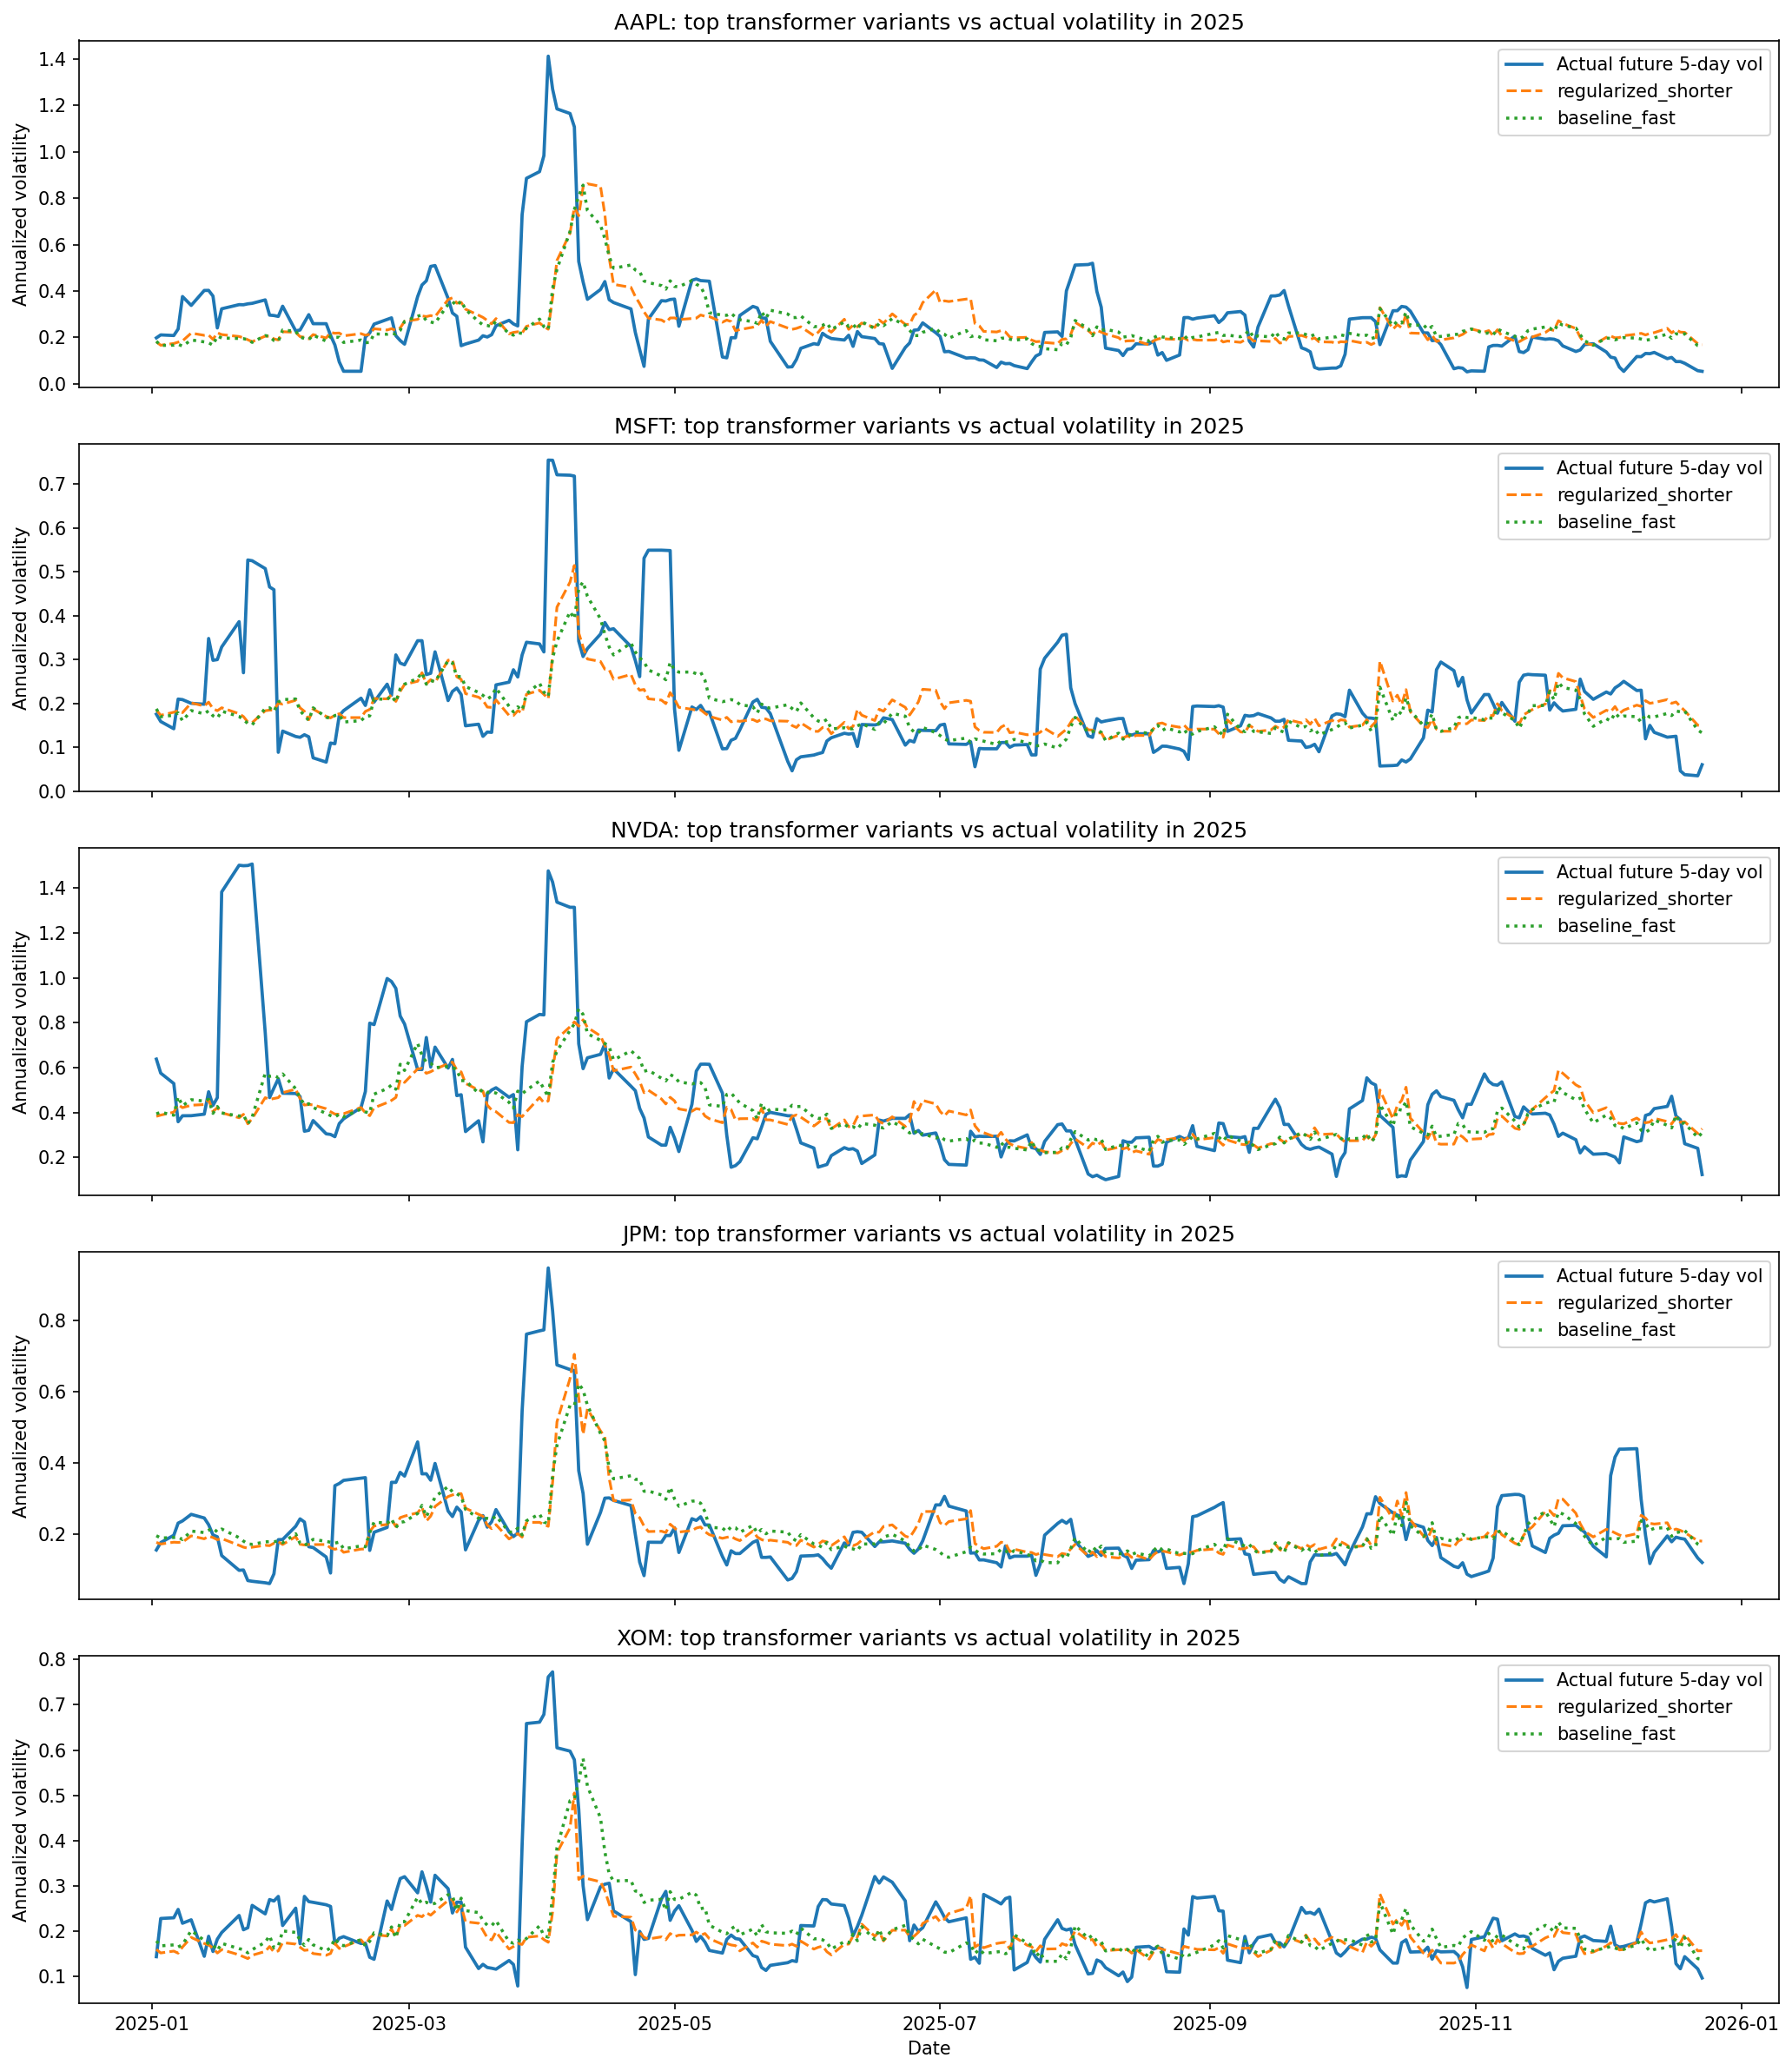

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/transformer_antioverfit_feature_review_5stocks.png')

In [8]:
top_two = experiment_summary_df['experiment'].head(2).tolist()
plot_df = test_prediction_map[top_two[0]].rename(columns={'prediction': top_two[0]})
plot_df = plot_df.merge(
    test_prediction_map[top_two[1]][['Date', 'Ticker', 'prediction']].rename(columns={'prediction': top_two[1]}),
    on=['Date', 'Ticker'],
    how='left',
)

fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 16), sharex=True)

for ax, ticker in zip(axes, selected_tickers):
    stock_plot_df = plot_df[plot_df['Ticker'] == ticker].sort_values('Date')
    ax.plot(stock_plot_df['Date'], stock_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.8)
    ax.plot(stock_plot_df['Date'], stock_plot_df[top_two[0]], label=top_two[0], linestyle='--', linewidth=1.5)
    ax.plot(stock_plot_df['Date'], stock_plot_df[top_two[1]], label=top_two[1], linestyle=':', linewidth=1.7)
    ax.set_title(f'{ticker}: top transformer variants vs actual volatility in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()

review_plot_path = FIGURE_DIR / 'transformer_antioverfit_feature_review_5stocks.png'
plt.savefig(review_plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(review_plot_path)))

review_plot_path

## How to interpret the result

Use the output in this order:

- first compare the `baseline_fast`, `regularized_small`, and `regularized_shorter` rows to see whether the main problem was overfitting,
- then compare `importance_guided_small` to the best fast-feature model to see whether the feature revision helped,
- finally use the XGBoost importance table as support for which features are worth keeping, adding, or dropping in the next notebook revision.